In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
df = pd.read_csv("/kaggle/input/datasets/veerkukreti/fraudulent/Fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
#these are identifiers, not behavioral features.
df = df.drop(["nameOrig", "nameDest"], axis=1)

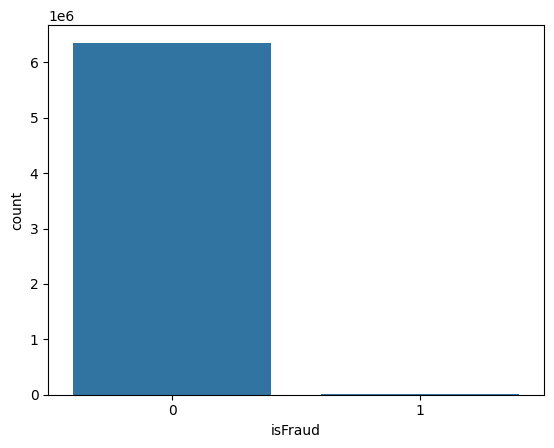

In [9]:
#Fraud distribution
sns.countplot(x="isFraud", data=df)
plt.show()

In [14]:
# fraud by transaction type
df.groupby("type")["isFraud"].sum()

type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64

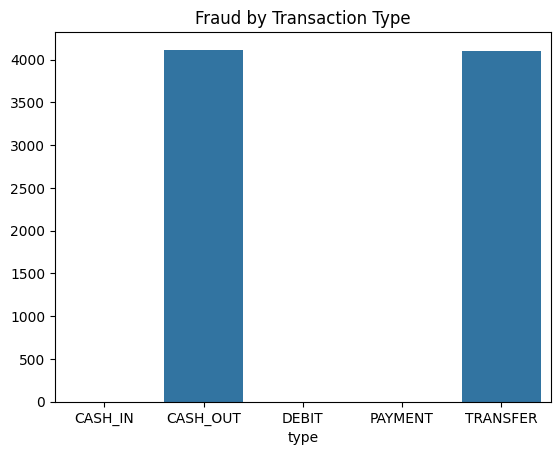

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x=df.groupby("type")["isFraud"].sum().index,
    y=df.groupby("type")["isFraud"].sum().values
)

plt.title("Fraud by Transaction Type")
plt.show()

In [16]:
df = pd.get_dummies(df, columns=["type"])

In [17]:
df.groupby("type_TRANSFER")["isFraud"].sum()

type_TRANSFER
False    4116
True     4097
Name: isFraud, dtype: int64

In [18]:
df.columns

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'type_CASH_IN',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')

In [19]:
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1,0,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,False,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,False,False,False,True,False


In [22]:
df[["type_CASH_IN","type_CASH_OUT","type_DEBIT","type_PAYMENT","type_TRANSFER","isFraud"]].groupby(
    ["type_CASH_IN","type_CASH_OUT","type_DEBIT","type_PAYMENT","type_TRANSFER"]
)["isFraud"].sum()

type_CASH_IN  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER
False         False          False       False         True             4097
                                         True          False               0
                             True        False         False               0
              True           False       False         False            4116
True          False          False       False         False               0
Name: isFraud, dtype: int64

In [24]:
fraud_by_type = {
    "CASH_IN": df[df["type_CASH_IN"] == 1]["isFraud"].sum(),
    "CASH_OUT": df[df["type_CASH_OUT"] == 1]["isFraud"].sum(),
    "DEBIT": df[df["type_DEBIT"] == 1]["isFraud"].sum(),
    "PAYMENT": df[df["type_PAYMENT"] == 1]["isFraud"].sum(),
    "TRANSFER": df[df["type_TRANSFER"] == 1]["isFraud"].sum()
}

print(fraud_by_type)

{'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(4116), 'DEBIT': np.int64(0), 'PAYMENT': np.int64(0), 'TRANSFER': np.int64(4097)}


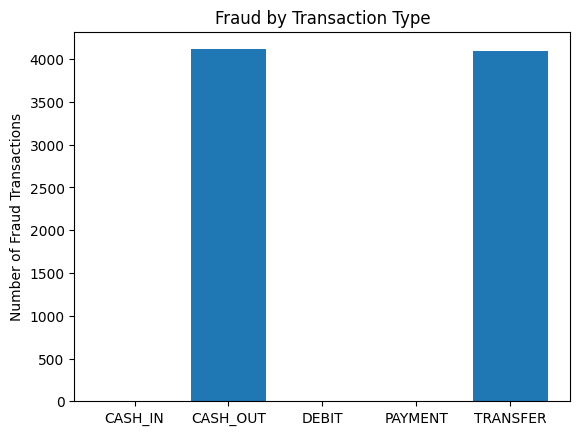

In [25]:
fraud_counts = [
    df[df["type_CASH_IN"] == 1]["isFraud"].sum(),
    df[df["type_CASH_OUT"] == 1]["isFraud"].sum(),
    df[df["type_DEBIT"] == 1]["isFraud"].sum(),
    df[df["type_PAYMENT"] == 1]["isFraud"].sum(),
    df[df["type_TRANSFER"] == 1]["isFraud"].sum()
]

types = ["CASH_IN","CASH_OUT","DEBIT","PAYMENT","TRANSFER"]

import matplotlib.pyplot as plt

plt.bar(types, fraud_counts)
plt.title("Fraud by Transaction Type")
plt.ylabel("Number of Fraud Transactions")
plt.show()

In [26]:
df.duplicated().sum()

np.int64(543)

In [27]:
df = df.drop_duplicates()

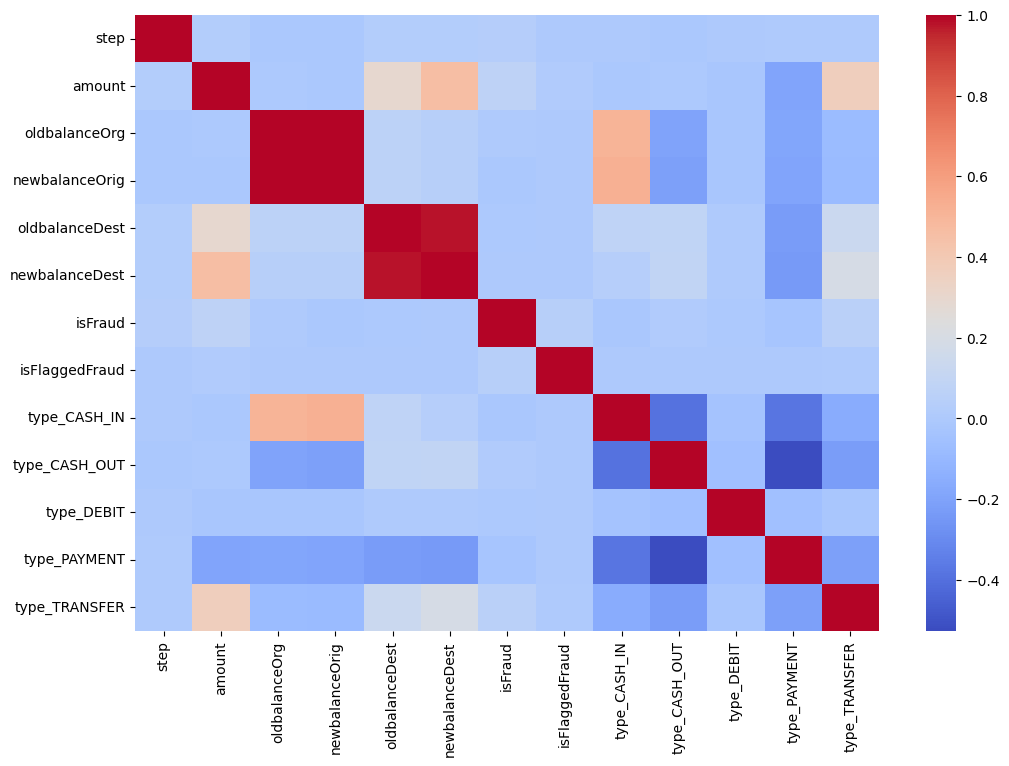

In [29]:
corr = df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()
#checking for multi collinearity

In [31]:
df.loc[:, "balance_diff_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df.loc[:, "balance_diff_dest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [32]:
#preparing training data
X = df.drop(["isFraud","isFlaggedFraud"], axis=1)
y = df["isFraud"]

In [33]:
#splitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
#handling class imbalances
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

In [35]:
#q2 training frouad data
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [36]:
# model evaluation
predictions = model.predict(X_test)

In [37]:
#classification report\
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270787
           1       0.98      0.80      0.88      1629

    accuracy                           1.00   1272416
   macro avg       0.99      0.90      0.94   1272416
weighted avg       1.00      1.00      1.00   1272416



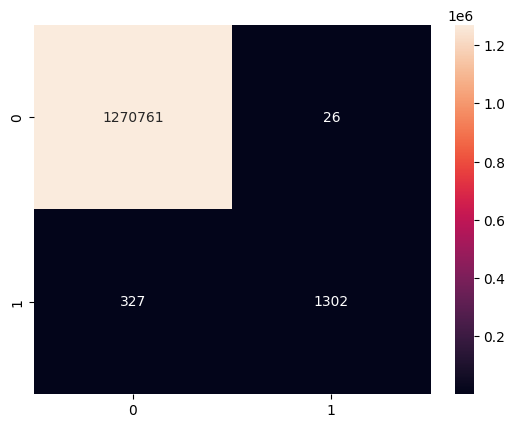

In [38]:
#confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.show()

In [39]:
#checking the roc auc
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

np.float64(0.9953175565417214)

In [40]:
#feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

balance_diff_orig    0.272870
oldbalanceOrg        0.172648
amount               0.121128
newbalanceOrig       0.116621
balance_diff_dest    0.069210
type_TRANSFER        0.059935
type_PAYMENT         0.044518
step                 0.040636
newbalanceDest       0.037754
type_CASH_IN         0.026922
oldbalanceDest       0.020831
type_CASH_OUT        0.016595
type_DEBIT           0.000332
dtype: float64


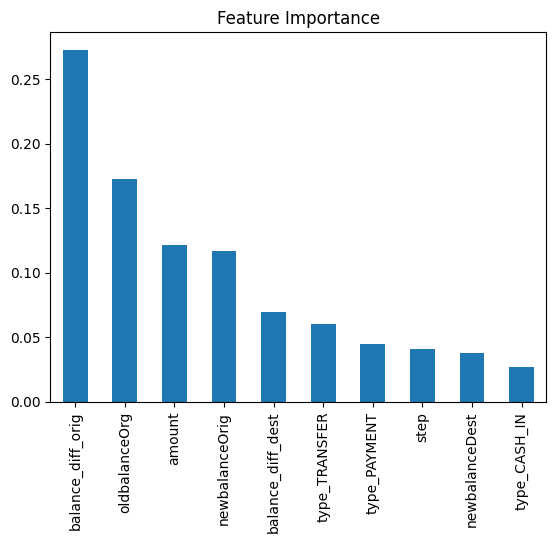

In [41]:
#viz
importance.head(10).plot(kind="bar")
plt.title("Feature Importance")
plt.show()